In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn import datasets, tree
from sklearn.metrics import make_scorer, f1_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

1. Завантажуємо дані набору Iris за допомогою функції load_iris() з бібліотеки sklearn.

In [4]:
dataset = datasets.load_iris()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
df = pd.DataFrame(data=dataset['data'], columns=dataset['feature_names'])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


2. Додаємо описовий аналіз даних.

In [45]:
print(dataset.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [49]:
# 0,1,2 = target names відповідно ['setosa' 'versicolor' 'virginica']
print(dataset.target) 
print(dataset.target_names)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [50]:
df_target_iris = pd.DataFrame(dataset['target'], columns =[ 'iris_type']) # створюємо датафрейм з цільовою змінною
df_iris_all = pd.concat([df, df_target_iris], axis=1)
df_iris_all.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


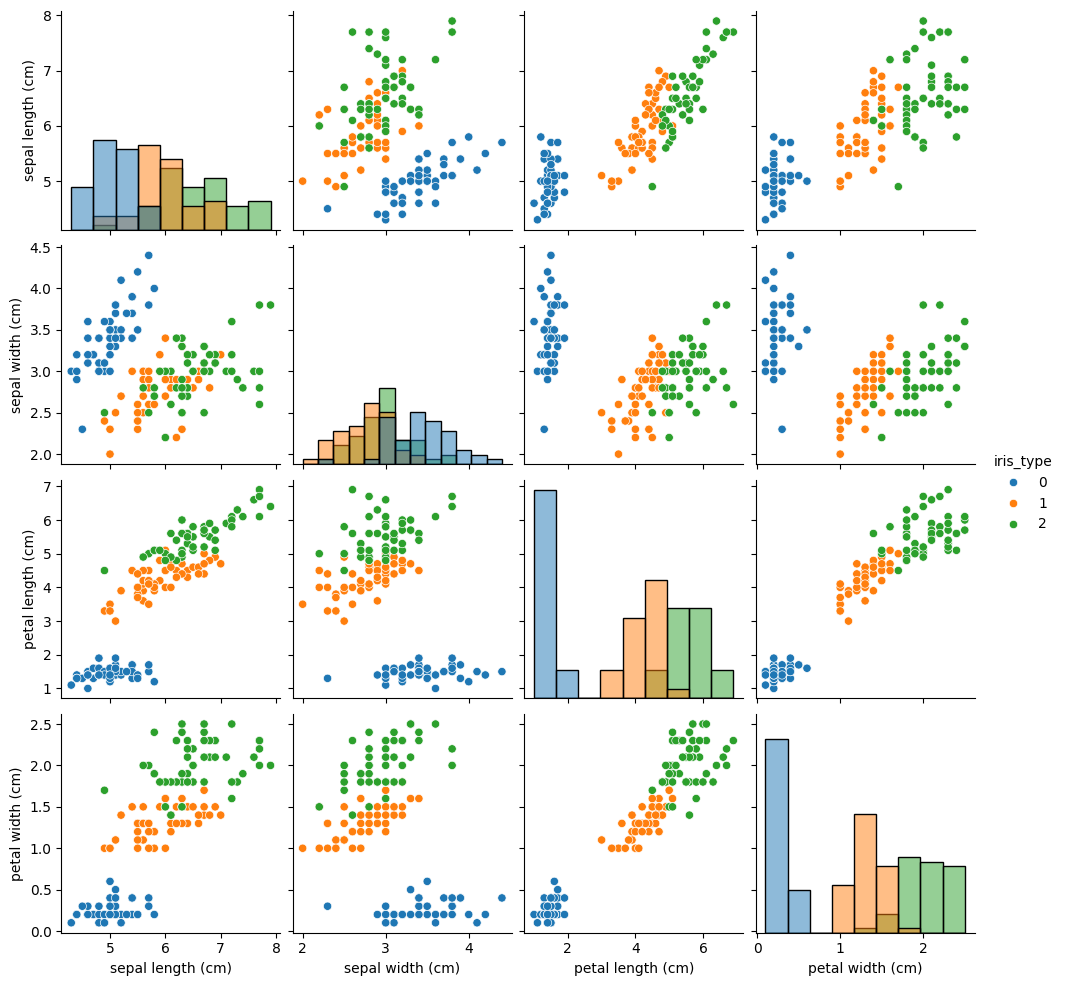

In [9]:
sns.pairplot(df_iris_all, hue='iris_type', palette= "tab10", diag_kind='hist')

In [10]:
def data_scale(dataset, scaler_type='std'):
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import Normalizer
    if scaler_type == 'std':
        scaler = StandardScaler()
    elif scaler_type == 'norm':
        scaler = Normalizer()
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()
    else:
        print("Scaler Type Undefined")
        return None
    scaler.fit(dataset)
    res = scaler.transform(dataset)
    return res

In [11]:
df_scaled = data_scale(df, 'std')
df_scaled = pd.DataFrame(df_scaled, columns = df.columns)
df_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


3. Виконуємо розділення набору даних для частини тренування та тестування - train_test_split() ф-ція з біблітеки sklearn.

In [51]:
X, y = df_scaled, df_target_iris
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

4. Створюємо класифікатор на основі дерев розв'язків.

Для цього використовується функція DecisionTreeClassifier() з бібліотеки sklearn.

In [13]:
from sklearn.tree import DecisionTreeClassifier

clf_tree = DecisionTreeClassifier(max_depth=10, random_state=1)
clf_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=1)

 5. cross_val_test() для порівняння ефективності роботи класифікатора на даних для тестування та тренування у випадку використання крос-валідації.

In [14]:
def cross_test_val(model, dataX, dataY, model_type='classification', folds=5):
    cv = KFold(n_splits=folds, shuffle=True, random_state=1)
    if model_type == "regression":
        scorer={
            'mse': make_scorer(mean_squared_error),
            'r2': make_scorer(r2_score),
            'mae': make_scorer(mean_absolute_error),
            'mape': make_scorer(mean_absolute_percentage_error)
        }

    if model_type == 'classification':
        scorer = {'f1':make_scorer(f1_score, average='micro')}
    scores = cross_validate(model, dataX, dataY, scoring=scorer, cv=cv, return_train_score=True)
    return scores

In [15]:
cross_test_val(clf_tree, X, y)

{'fit_time': array([0.00176525, 0.00097203, 0.00071812, 0.0006969 , 0.00081301]),
 'score_time': array([0.00214386, 0.00099301, 0.00091004, 0.00115204, 0.0009079 ]),
 'test_f1': array([0.96666667, 0.96666667, 0.96666667, 0.93333333, 0.83333333]),
 'train_f1': array([1., 1., 1., 1., 1.])}

In [54]:
# text.export_text() - виводить текстове представлення дерева рішень
text_representation_iris = tree.export_text(clf_tree)
print(text_representation_iris)

|--- feature_3 <= -0.53
|   |--- class: 0
|--- feature_3 >  -0.53
|   |--- feature_2 <= 0.56
|   |   |--- class: 1
|   |--- feature_2 >  0.56
|   |   |--- feature_3 <= 0.72
|   |   |   |--- feature_2 <= 0.68
|   |   |   |   |--- class: 1
|   |   |   |--- feature_2 >  0.68
|   |   |   |   |--- feature_3 <= 0.46
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- feature_3 >  0.46
|   |   |   |   |   |--- feature_0 <= 1.34
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_0 >  1.34
|   |   |   |   |   |   |--- class: 2
|   |   |--- feature_3 >  0.72
|   |   |   |--- feature_2 <= 0.62
|   |   |   |   |--- feature_0 <= 0.13
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_0 >  0.13
|   |   |   |   |   |--- class: 2
|   |   |   |--- feature_2 >  0.62
|   |   |   |   |--- class: 2



6. Візуалізація отриманого дерева розв'язку за допомогою функції plot_tree() модуля tree бібліотеки sklearn.

In [57]:
list(df.columns)

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [59]:
dataset.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

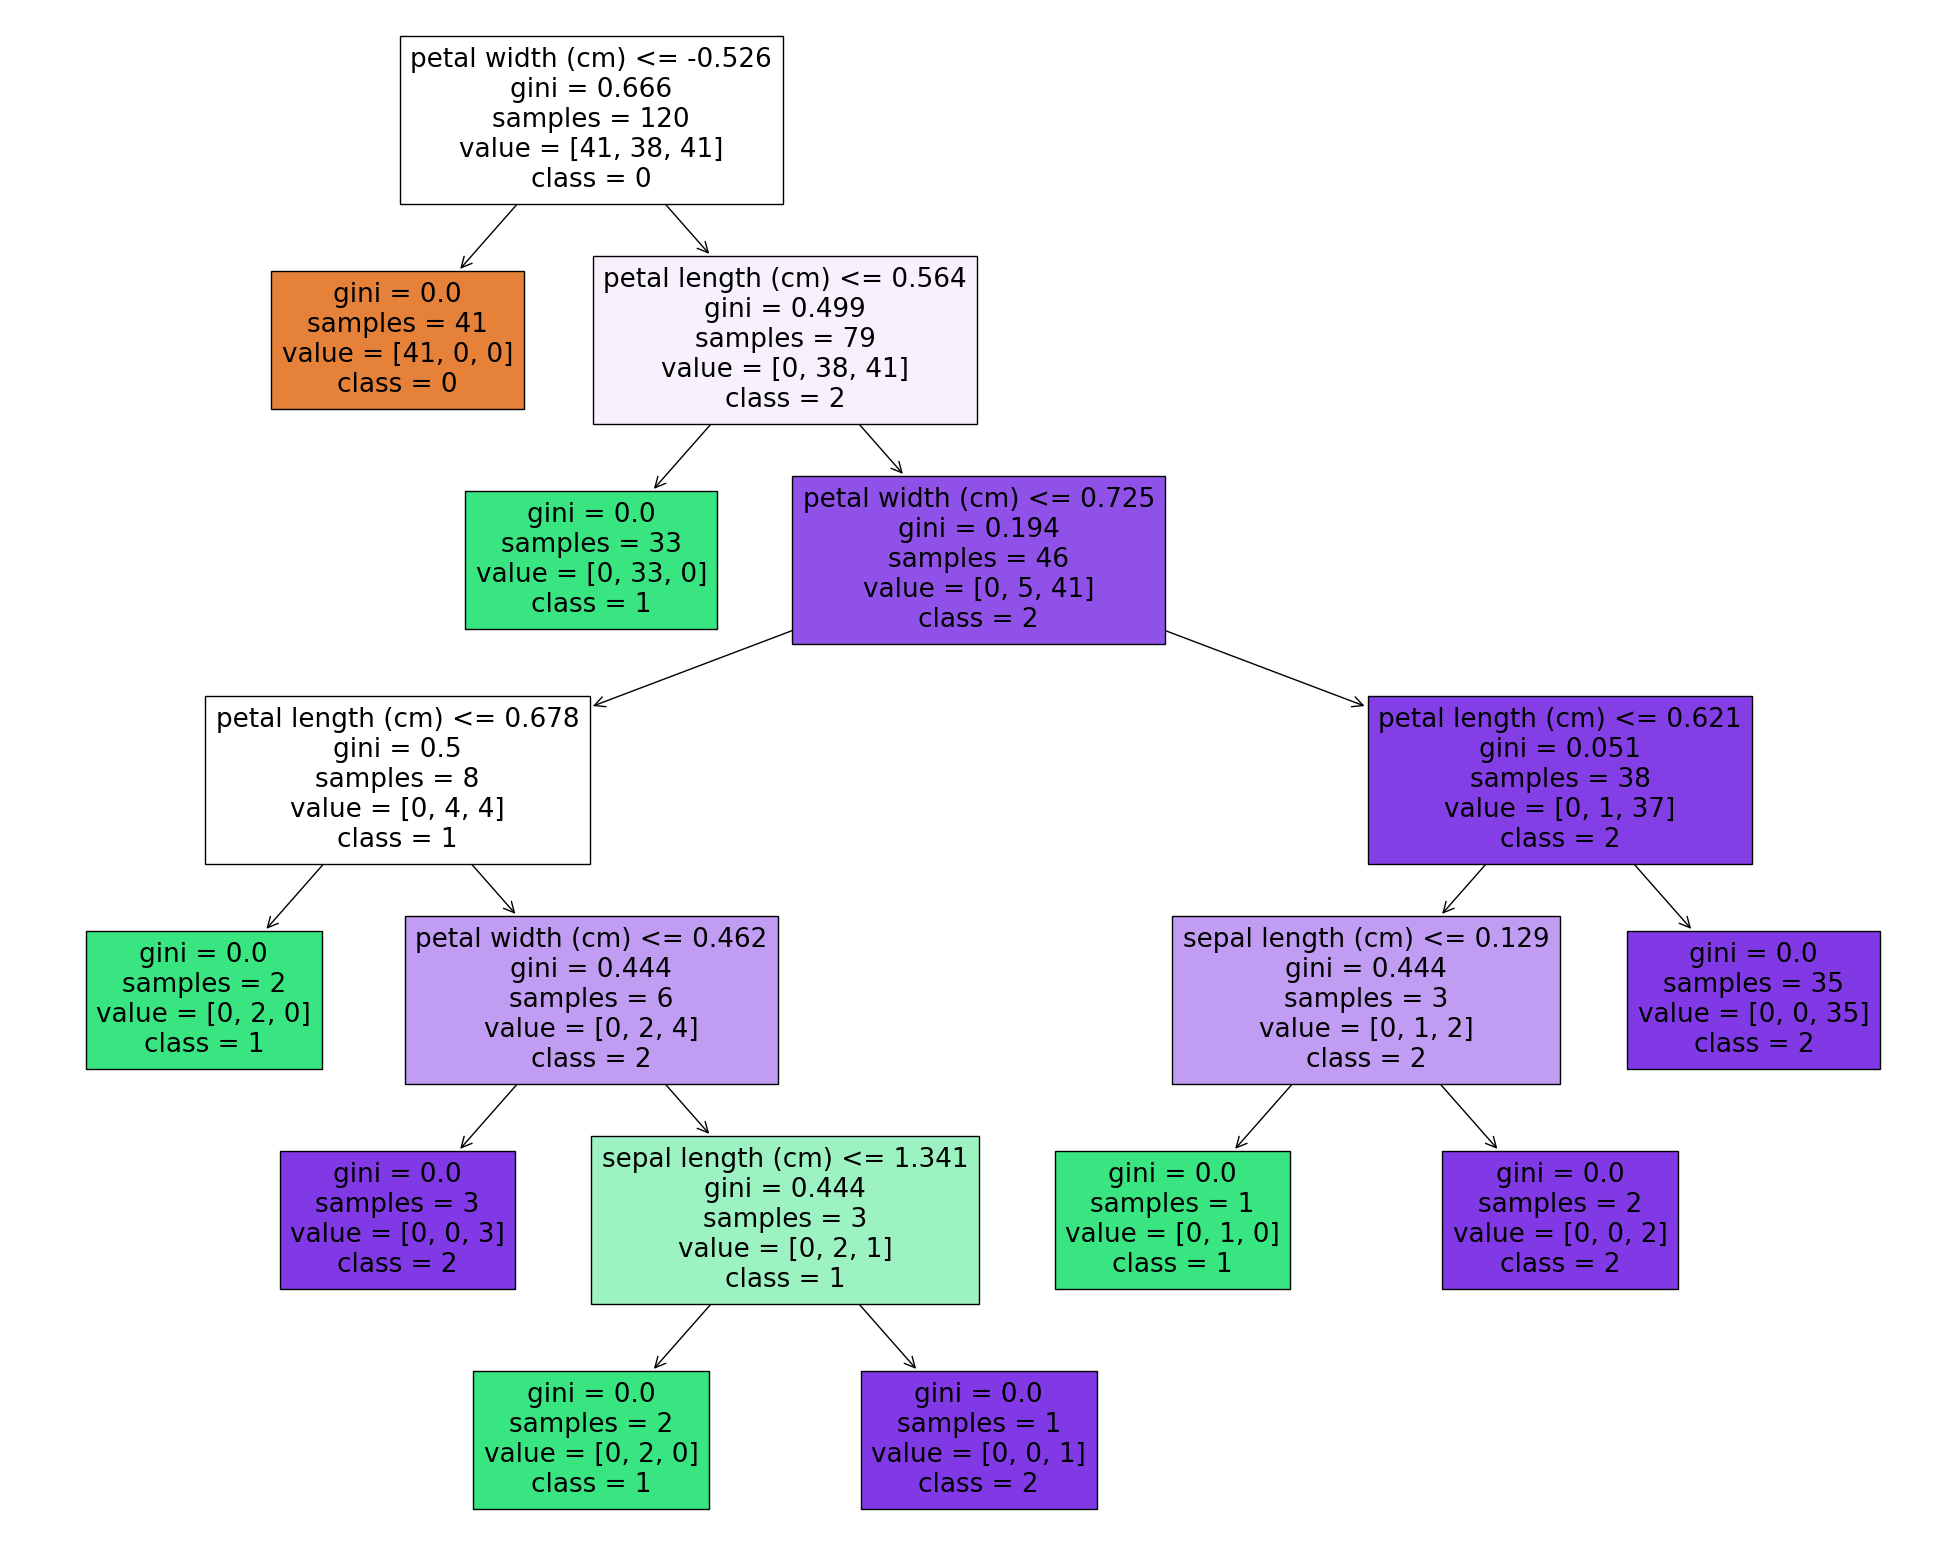

In [ ]:
plt.figure(figsize=(25,20))
tree.plot_tree(
    clf_tree,
    feature_names=list(dataset.feature_names),
    # class_names=list(dataset.target_names),
    class_names=['0','1','2'],
    filled=True
)
plt.show()

#### Decision Tree (Дерево рішень) EXPLAINED
- Each node represents a decision rule, and leaf nodes represent final predictions.
- Дерево рішень послідовно ділить дані умовами так, щоб у кожній групі залишались максимально схожі об'єкти(true -> left, false -> right)
- samples - кількість зразків, які потрапили в дану вершину
- value - кількість зразків кожного класу, які потрапили в дану вершину
- gini - вказує ступінь неоднорідності вибірки (чим менше, тим краще, 0 - всі зразки одного класу)


7. Візуалізація границі прийняття рішення за допомогою функції DecisionBoundaryDisplay() бібліотеки sklearn.

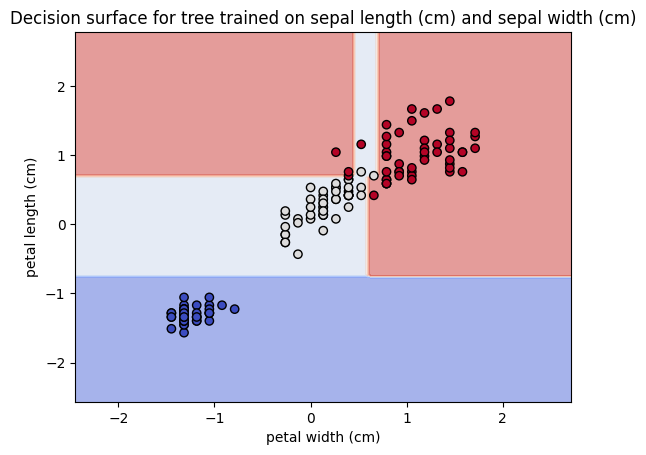

In [17]:
from sklearn.inspection import DecisionBoundaryDisplay

# choosing two features
X_train_2 = X[['petal width (cm)','petal length (cm)']]

# Creating and fitting the tree classifier
model = DecisionTreeClassifier(max_depth=4, random_state=1)
model.fit(X_train_2, y)

# Plotting the tree boundaries
display = DecisionBoundaryDisplay.from_estimator(
    model,
    X_train_2,
    response_method='predict', # method to predict response for each point ('predict', 'predict_proba', 'decision_function')
    alpha=0.5, # transparency of the decision boundary
    cmap=plt.cm.coolwarm
)

# Plotting the data points
display.ax_.scatter(
    X['petal width (cm)'], X['petal length (cm)'],
    c=df_iris_all['iris_type'],
    edgecolors='k',
    cmap=plt.cm.coolwarm
)

plt.title(f"Decision surface for tree trained on {dataset.feature_names[0]} and {dataset.feature_names[1]}")
plt.show()

8. Класифікатор випадковий ліс за допомогою функції RandomForestClassifier.

In [18]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(max_depth=2, random_state=3)
clf_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, random_state=3)

9. Точність класифікатора за допомогою функції cross_val_test().

In [23]:
cross_test_val(
    model=clf_rf,
    dataX=X,
    dataY=y,
    model_type='classification',
    folds=5
)

{'fit_time': array([0.07104683, 0.04536986, 0.0439539 , 0.04747605, 0.04408813]),
 'score_time': array([0.00282907, 0.00263691, 0.00284696, 0.00258183, 0.00257683]),
 'test_f1': array([0.96666667, 0.96666667, 0.96666667, 0.86666667, 0.9       ]),
 'train_f1': array([0.95      , 0.95      , 0.96666667, 0.975     , 0.96666667])}

10. Обчислювальні екперименти та оцінка оптимального набору гіперпараметрів за результатами експериментів.


In [40]:
# Experiment 1
clf_rf1 = RandomForestClassifier(n_estimators=5, max_depth=5, random_state=3)
clf_rf1.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, n_estimators=5, random_state=3)

In [41]:
cross_test_val(clf_rf1, X,y,model_type='classification')

{'fit_time': array([0.01089907, 0.00615811, 0.00689411, 0.00504589, 0.0047102 ]),
 'score_time': array([0.00400615, 0.0025208 , 0.0028758 , 0.00159001, 0.00170898]),
 'test_f1': array([0.96666667, 0.96666667, 0.96666667, 0.93333333, 0.9       ]),
 'train_f1': array([0.98333333, 0.975     , 1.        , 0.98333333, 0.98333333])}

In [42]:
# Experiment 2
clf_rf2 = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=3)
clf_rf2.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, n_estimators=10, random_state=3)

In [43]:
cross_test_val(clf_rf2, X,y,model_type='classification')

{'fit_time': array([0.01193094, 0.00961828, 0.00848198, 0.00564599, 0.00571275]),
 'score_time': array([0.00184894, 0.00234985, 0.0015099 , 0.00118923, 0.00136614]),
 'test_f1': array([0.96666667, 0.96666667, 0.93333333, 0.93333333, 0.93333333]),
 'train_f1': array([0.99166667, 1.        , 0.99166667, 0.99166667, 0.99166667])}